## Tarea 1
### Materia: Laboratorio de Aprendizaje Estádistico 
### Profesor: Antonio Manguart Paez
### Alumna: Maria Fernanda Gómez Flores

## Instrucciones

Crea una regresión lineal con los demás inputs numericos

'housing_median_age', 'total_rooms',
'total_bedrooms', 'population', 'households'

Y también crea estas 2 variables y a su vez la regresion lineal:
rooms per household
bed rooms per household 

- Realiza un analisis bivariado de cada uno de estos
- Escribe la ecuación del modelo 
- Obtener R2 y mean squared error
- Grafica las predicciones 

Responde la pregunta: ¿Cuál es el mejor modelo de estos? ¿Por qué?

## Preparación de datos

In [1295]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
import numpy as np

In [1296]:
df = pd.read_csv('housing.csv')

In [1297]:
df.isna().mean()

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        0.010029
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

In [1298]:
df = df.fillna(df.mean(numeric_only=True))

In [1299]:
df.isna().mean()

longitude             0.0
latitude              0.0
housing_median_age    0.0
total_rooms           0.0
total_bedrooms        0.0
population            0.0
households            0.0
median_income         0.0
median_house_value    0.0
ocean_proximity       0.0
dtype: float64

In [1300]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


## 'housing_median_age'

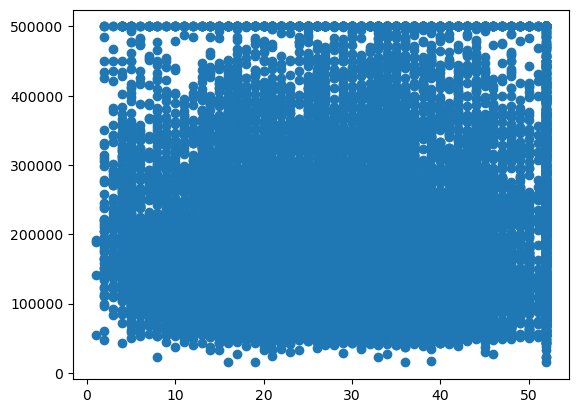

In [1301]:
# Grafica housing median age vs precio 
plt.scatter(df.housing_median_age, df.median_house_value)

In [1302]:
# Elimina los máximos de precio casa
df1  = df.query("median_house_value < 500001")

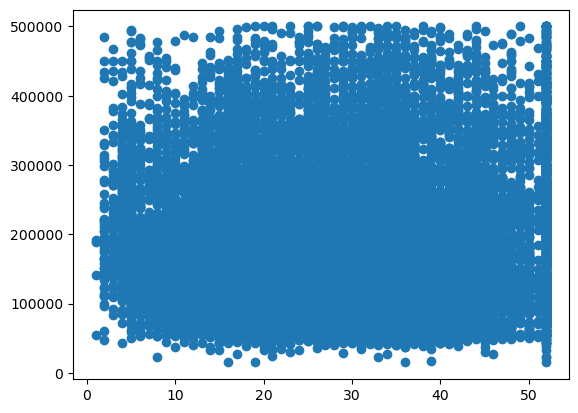

In [1303]:
# Grafica sin los máximos
plt.scatter(df1.housing_median_age, df1.median_house_value)

In [1304]:
# Crea una regreson lineal
model = linear_model.LinearRegression()

X = df1[['housing_median_age']]
y = df1['median_house_value']

model.fit(X, y)

LinearRegression()

In [1305]:
#Intercepto Valor mínimo que va a valer una casa
model.intercept_

np.float64(177411.79806093415)

In [1306]:
model.coef_

array([530.7537496])

Coeficiente: Por cada año de housing_median_age, cuanto tiende a crecer el valor de su casa

$$Precio = 177411 + 530 * housing\_median\_age$$

In [1307]:
predicciones_housing_median_age = model.predict(X)

In [1308]:
from sklearn.metrics import mean_squared_error

In [1309]:
mse_housing_median_age=mean_squared_error(y_pred=predicciones_housing_median_age, y_true=y)
mse_housing_median_age

9502976334.705992

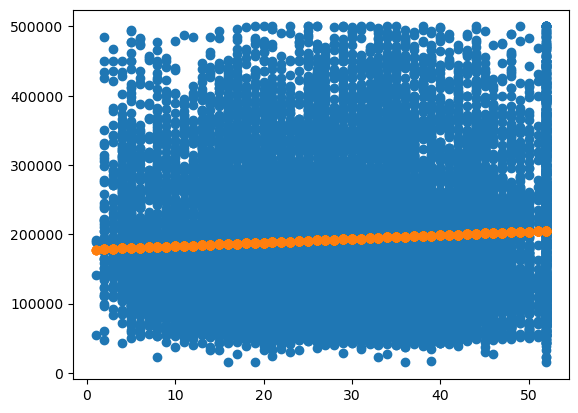

In [1310]:
plt.scatter(df1.housing_median_age, df1.median_house_value)
plt.scatter(df1.housing_median_age, predicciones_housing_median_age)

In [1311]:
from sklearn.metrics import r2_score

In [1312]:
r2_housing_median_age=r2_score(y_pred=predicciones_housing_median_age, y_true=y)
r2_housing_median_age


0.004616870761556036

Conceptualmente: el modelo es un 0.46% mejor que simplemente dar el precio promedio de las casas como estimación 

## 'population'

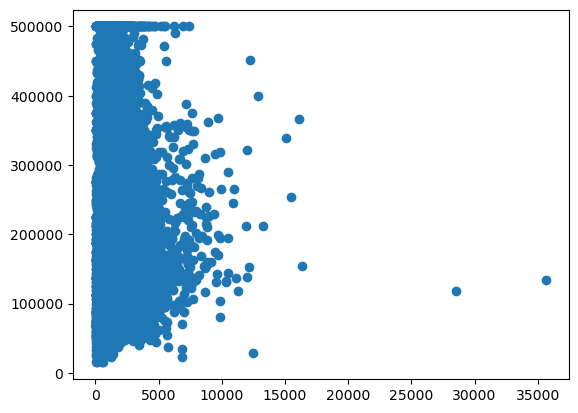

In [1313]:
# Grafica 'total_rooms' vs population 
plt.scatter(df.population, df.median_house_value)

In [1314]:
# Elimina los máximos de precio casa
df1  = df.query("median_house_value < 500001")

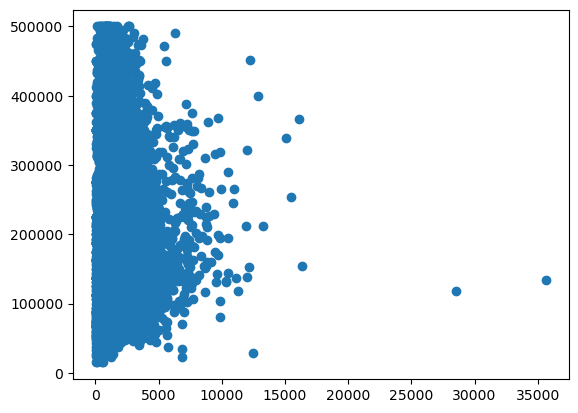

In [1315]:
# Grafica sin los máximos
plt.scatter(df1.population, df1.median_house_value)

In [1316]:
# Crea una regreson lineal
model = linear_model.LinearRegression()

X = df1[['population']]
y = df1['median_house_value']

model.fit(X, y)

LinearRegression()

In [1317]:
#Intercepto Valor mínimo que va a valer una casa
model.intercept_

np.float64(191005.0921058971)

In [1318]:
model.coef_

array([1.02222129])

Coeficiente: Por cada persona en population, cuanto tiende a crecer el valor de su casa

$$Precio = 191005 + 1 * population$$

In [1319]:
predicciones_population = model.predict(X)

In [1320]:
from sklearn.metrics import mean_squared_error

In [1321]:
mse_population=mean_squared_error(y_pred=predicciones_population, y_true=y)
mse_population

9545687211.793383

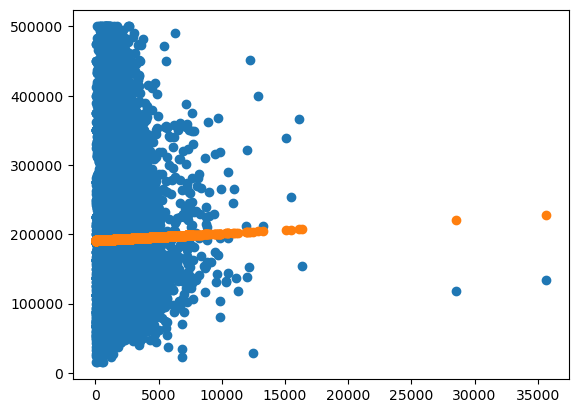

In [1322]:
plt.scatter(df1.population, df1.median_house_value)
plt.scatter(df1.population, predicciones_population)

In [1323]:
from sklearn.metrics import r2_score

In [1324]:
r2_population=r2_score(y_pred=predicciones_population, y_true=y)
r2_population


0.00014314747840926678

Conceptualmente: el modelo es un 0.014% mejor que simplemente dar el precio promedio de las casas como estimación 

## 'total_bedrooms'

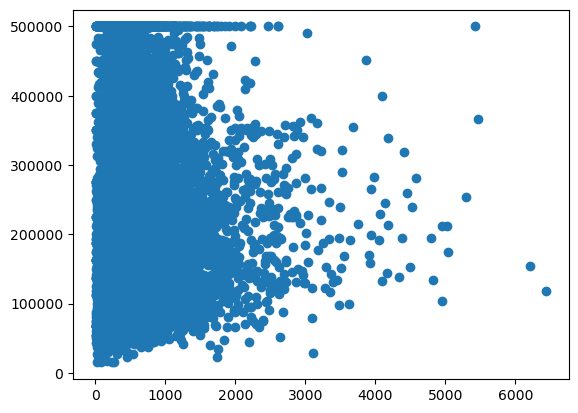

In [1325]:
# Grafica 'total_bedrooms' vs precio 
plt.scatter(df.total_bedrooms, df.median_house_value)

In [1326]:
# Elimina los máximos de precio casa
df1  = df.query("median_house_value < 500001")

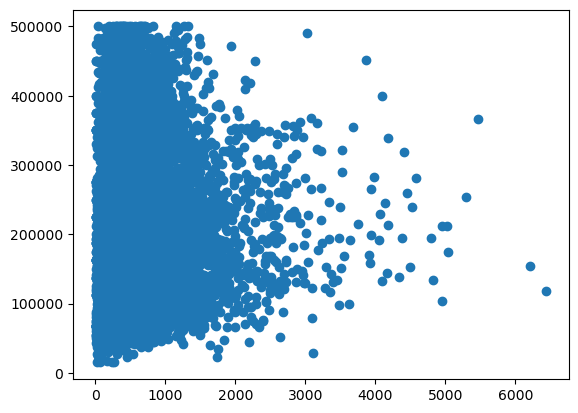

In [1327]:
# Grafica sin los máximos
plt.scatter(df1.total_bedrooms, df1.median_house_value)

In [1328]:
# Crea una regreson lineal
model = linear_model.LinearRegression()

X = df1[['total_bedrooms']]
y = df1['median_house_value']

model.fit(X, y)

LinearRegression()

In [1329]:
#Intercepto Valor mínimo que va a valer una casa
model.intercept_

np.float64(183158.00846522846)

In [1330]:
model.coef_

array([17.27100453])

Coeficiente: Por cada recamara de total_bedrooms, cuanto tiende a crecer el valor de su casa

$$Precio = 183158 + 17 * total\_bedrooms$$

In [1331]:
predicciones_total_bedrooms = model.predict(X)

In [1332]:
from sklearn.metrics import mean_squared_error

In [1333]:
mse_total_bedrooms=mean_squared_error(y_pred=predicciones_total_bedrooms, y_true=y)
mse_total_bedrooms

9494373254.760687

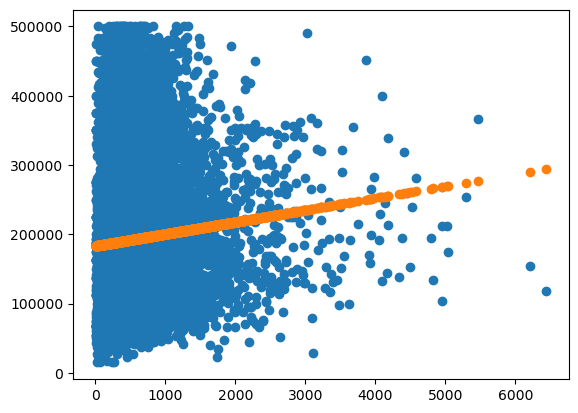

In [1334]:
plt.scatter(df1.total_bedrooms, df1.median_house_value)
plt.scatter(df1.total_bedrooms, predicciones_total_bedrooms)

In [1335]:
from sklearn.metrics import r2_score

In [1336]:
r2_total_bedrooms=r2_score(y_pred=predicciones_total_bedrooms, y_true=y)
r2_total_bedrooms


0.005517994823684869

Conceptualmente: el modelo es un 0.5% mejor que simplemente dar el precio promedio de las casas como estimación 

## 'total_rooms'

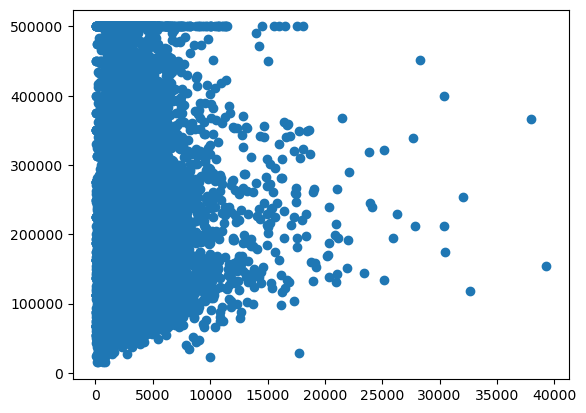

In [1337]:
# Grafica 'total_rooms' vs precio 
plt.scatter(df.total_rooms, df.median_house_value)

In [1338]:
# Elimina los máximos de precio casa
df1  = df.query("median_house_value < 500001")

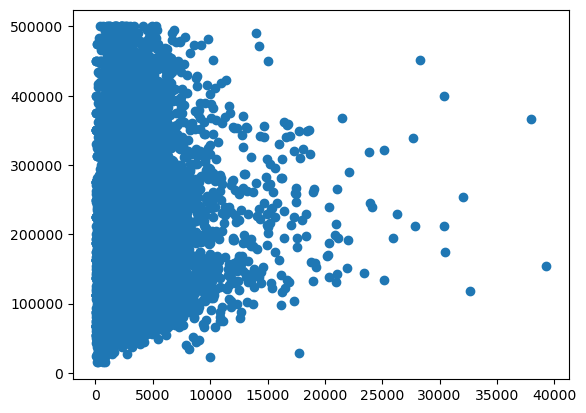

In [1339]:
# Grafica sin los máximos
plt.scatter(df1.total_rooms, df1.median_house_value)

In [1340]:
# Crea una regreson lineal
model = linear_model.LinearRegression()

X = df1[['total_rooms']]
y = df1['median_house_value']

model.fit(X, y)

LinearRegression()

In [1341]:
#Intercepto Valor mínimo que va a valer una casa
model.intercept_

np.float64(175680.60158723383)

In [1342]:
model.coef_

array([6.411769])

Coeficiente: Por cada cuarto de total_rooms, cuanto tiende a crecer el valor de su casa

$$Precio = 175680 + 6 * total\_rooms$$

In [1343]:
predicciones_total_rooms = model.predict(X)

In [1344]:
from sklearn.metrics import mean_squared_error

In [1345]:
mse_total_rooms=mean_squared_error(y_pred=predicciones_total_rooms, y_true=y)
mse_total_rooms

9351447180.215872

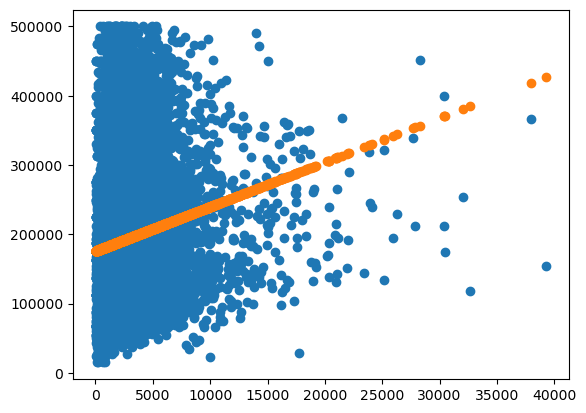

In [1346]:
plt.scatter(df1.total_rooms, df1.median_house_value)
plt.scatter(df1.total_rooms, predicciones_total_rooms)

In [1347]:
from sklearn.metrics import r2_score

In [1348]:
r2_total_rooms=r2_score(y_pred=predicciones_total_rooms, y_true=y)
r2_total_rooms


0.020488694351854075

Conceptualmente: el modelo es un 2.05% mejor que simplemente dar el precio promedio de las casas como estimación 

## 'households'

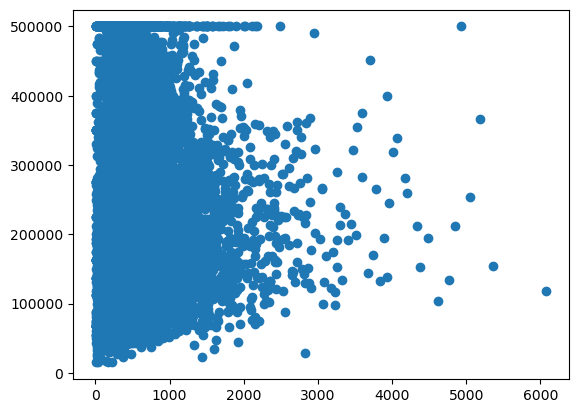

In [1349]:
# Grafica 'households' vs precio 
plt.scatter(df.households, df.median_house_value)

In [1350]:
# Elimina los máximos de precio casa
df1  = df.query("median_house_value < 500001")

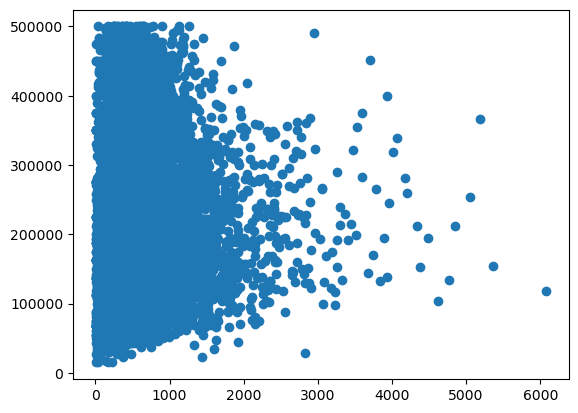

In [1351]:
# Grafica sin los máximos
plt.scatter(df1.households, df1.median_house_value)

In [1352]:
# Crea una regreson lineal
model = linear_model.LinearRegression()

X = df1[['households']]
y = df1['median_house_value']

model.fit(X, y)

LinearRegression()

In [1353]:
#Intercepto Valor mínimo que va a valer una casa
model.intercept_

np.float64(180352.83033455737)

In [1354]:
model.coef_

array([24.19279495])

Coeficiente: Por cada hogar adicional en households, cuanto tiende a crecer el valor de su casa

$$Precio = 180352 + 24 * households$$

In [1355]:
predicciones_households = model.predict(X)

In [1356]:
from sklearn.metrics import mean_squared_error

In [1357]:
mse_households=mean_squared_error(y_pred=predicciones_households, y_true=y)
mse_households

9461083732.794487

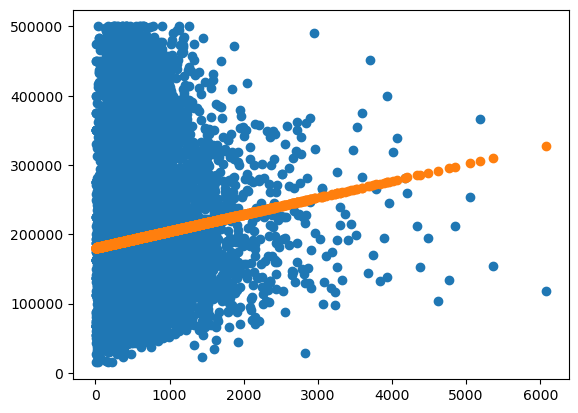

In [1358]:
plt.scatter(df1.households, df1.median_house_value)
plt.scatter(df1.households, predicciones_households)

In [1359]:
from sklearn.metrics import r2_score

In [1360]:
r2_households=r2_score(y_pred=predicciones_households, y_true=y)
r2_households


0.009004884338978392

Conceptualmente: el modelo es un 0.9% mejor que simplemente dar el precio promedio de las casas como estimación 

## 'rooms_per_household'

In [1361]:
df1['rooms_per_household'] = df1['total_rooms'] / df1['households']

/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_70359/2548530326.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['rooms_per_household'] = df1['total_rooms'] / df1['households']


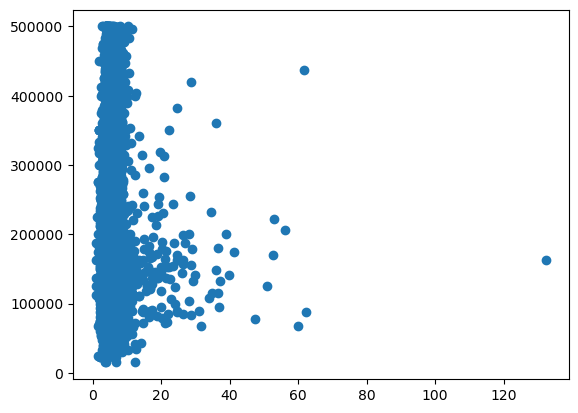

In [1362]:
# Grafica 'rooms_per_household' vs precio 
plt.scatter(df1.rooms_per_household, df1.median_house_value)

In [1363]:
# Elimina los máximos de precio casa
df2  = df1.query("median_house_value < 500001")

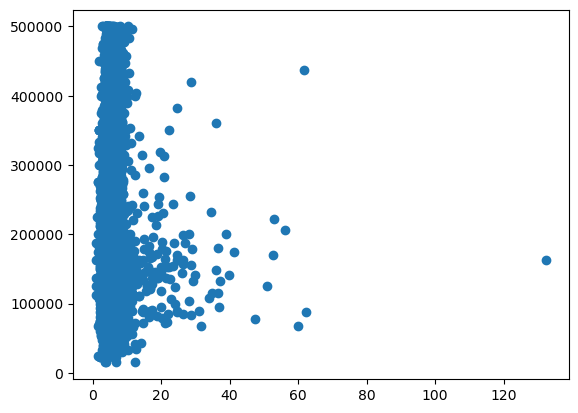

In [1364]:
# Grafica sin los máximos
plt.scatter(df2.rooms_per_household, df2.median_house_value)

In [1365]:
# Crea una regreson lineal
model = linear_model.LinearRegression()

X = df2[['rooms_per_household']]
y = df2['median_house_value']

model.fit(X, y)

LinearRegression()

In [1366]:
#Intercepto Valor mínimo que va a valer una casa
model.intercept_

np.float64(167418.83383507395)

In [1367]:
model.coef_

array([4674.41701427])

Coeficiente: Por cada cuarto adicional en promedio por hogar de total_rooms, cuanto tiende a crecer el valor de su casa

$$Precio = 167418 + 4674 * rooms\_per\_household$$

In [1368]:
predicciones_rooms_per_household = model.predict(X)

In [1369]:
from sklearn.metrics import mean_squared_error

In [1370]:
mse_rooms_per_household=mean_squared_error(y_pred=predicciones_rooms_per_household, y_true=y)
mse_rooms_per_household

9432221039.628843

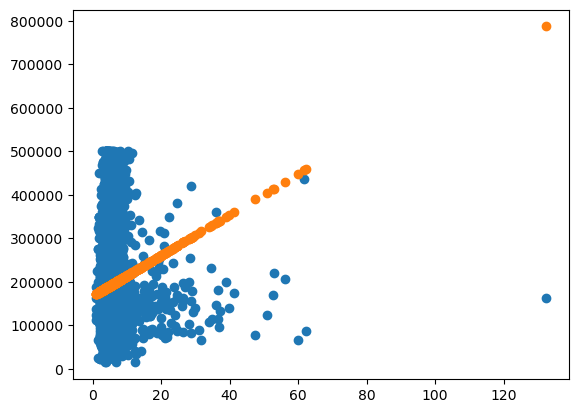

In [1371]:
plt.scatter(df2.rooms_per_household, df2.median_house_value)
plt.scatter(df2.rooms_per_household, predicciones_rooms_per_household)

In [1372]:
from sklearn.metrics import r2_score

In [1373]:
r2_rooms_per_household=r2_score(y_pred=predicciones_rooms_per_household, y_true=y)
r2_rooms_per_household


0.012028088525707137

Conceptualmente: el modelo es un 1.2% mejor que simplemente dar el precio promedio de las casas como estimación 

## 'bedrooms_per_household'

In [1374]:
df1['bedrooms_per_household'] = df1['total_bedrooms'] / df1['households']

/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_70359/3368722063.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['bedrooms_per_household'] = df1['total_bedrooms'] / df1['households']


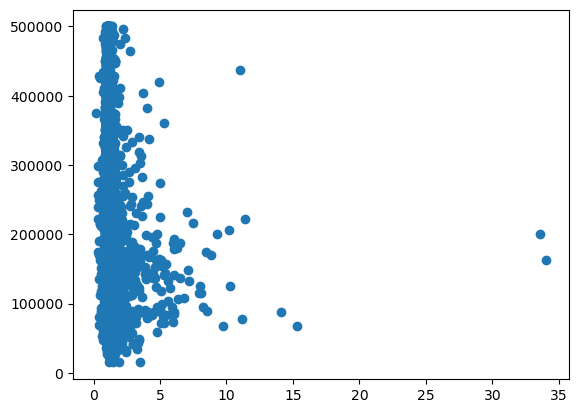

In [1375]:
# Grafica 'bedrooms_per_household' vs precio 
plt.scatter(df1.bedrooms_per_household, df1.median_house_value)

In [1376]:
# Elimina los máximos de precio casa
df2  = df1.query("median_house_value < 500001")

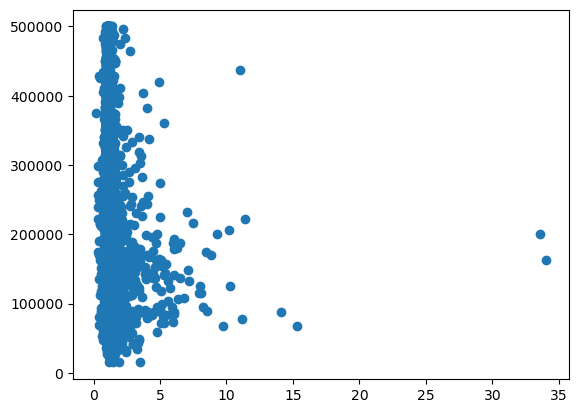

In [1377]:
# Grafica sin los máximos
plt.scatter(df2.bedrooms_per_household, df2.median_house_value)

In [1378]:
# Crea una regreson lineal
model = linear_model.LinearRegression()

X = df2[['bedrooms_per_household']]
y = df2['median_house_value']

model.fit(X, y)

LinearRegression()

In [1379]:
#Intercepto Valor mínimo que va a valer una casa
model.intercept_

np.float64(203839.44038720443)

In [1380]:
model.coef_

array([-10285.88015666])

Coeficiente: Por cada recamara adicional en promedio por hogar de total_bedrooms, cuanto tiende a crecer el valor de su casa

$$Precio = 203839 - 10285 * bedrooms\_per\_household$$

In [1381]:
predicciones_bedrooms_per_household = model.predict(X)

In [1382]:
from sklearn.metrics import mean_squared_error

In [1383]:
mse_bedrooms_per_household=mean_squared_error(y_pred=predicciones_bedrooms_per_household, y_true=y)
mse_bedrooms_per_household

9517524557.85723

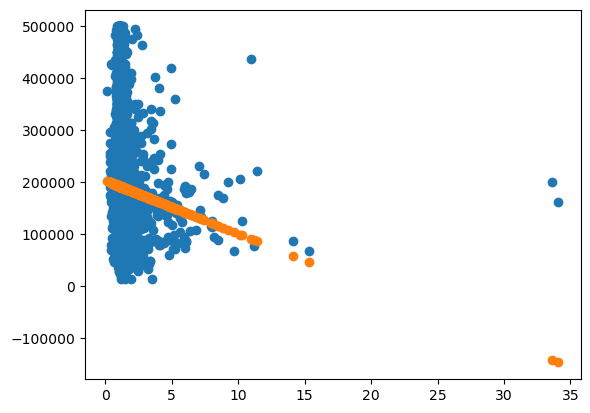

In [1384]:
plt.scatter(df2.bedrooms_per_household, df2.median_house_value)
plt.scatter(df2.bedrooms_per_household, predicciones_bedrooms_per_household)

In [1385]:
from sklearn.metrics import r2_score

In [1386]:
r2_bedrooms_per_household=r2_score(y_pred=predicciones_bedrooms_per_household, y_true=y)
r2_bedrooms_per_household


0.0030930265073877417

Conceptualmente: el modelo es un 0.31% mejor que simplemente dar el precio promedio de las casas como estimación 

## Comparación de Modelos y Resultados

In [1387]:
modelos = ["housing_median_age","population","total_bedrooms","total_rooms",
           "households","rooms_per_household","bedrooms_per_household"]

r2 = [r2_housing_median_age,r2_population,r2_total_bedrooms,r2_total_rooms,
      r2_households,r2_rooms_per_household,r2_bedrooms_per_household]

mse = [mse_housing_median_age,mse_population,mse_total_bedrooms,mse_total_rooms,
       mse_households,mse_rooms_per_household,mse_bedrooms_per_household]



In [1388]:
resultados = pd.DataFrame({
    "Modelo": modelos,
    "R2": r2,
    "MSE": mse
})

In [1391]:
resultados = resultados.sort_values(by=["R2","MSE"], ascending=[False,True])
resultados

,Modelo,R2,MSE
3,total_rooms,0.020489,9.351447e+09
5,rooms_per_household,0.012028,9.432221e+09
4,households,0.009005,9.461084e+09
2,total_bedrooms,0.005518,9.494373e+09
0,housing_median_age,0.004617,9.502976e+09
6,bedrooms_per_household,0.003093,9.517525e+09
1,population,0.000143,9.545687e+09


El mejor modelo es el de 'total_rooms' ya que cuenta con el R2 mas alto  y el MSE mas bajo.   
Es el modelo que mejor explica el precio y presenta el menor error de predicción